### Step P1 - Data Import and Initial Checks


In [ ]:
import pandas as pd

### Load dataset
df = pd.read_csv("survey_data.csv", sep=";")

print("Shape:", df.shape)
print("\nFirst 5 rows:\n", df.head(2))
print("\nData types (first 20 columns):\n", df.dtypes.head(20))

### Total missing values
print("\nTotal missing values in dataset:", df.isna().sum().sum())


Shape: (97, 29)

First 5 rows:
    perc.inv.lt.25  perc.inv.26.50  perc.inv.51.75  perc.inv.gt.75  \
0               0               0               1               0   
1               1               0               0               0   

   perc.reg.lt.25  perc.reg.26.50  perc.reg.51.75  perc.reg.75  env.little  \
0               0               1               0            0           1   
1               0               0               0            0           0   

   env.some  ...  imp.very  safe.little  safe.some  safe.very  max.lt.1  \
0         0  ...         0            0          1          0         0   
1         0  ...         0            0          1          0         0   

   max.1_2  max.2_2.5  max.gt.2.5  y.ipo  y.real  
0        0          0           1      0       0  
1        0          1           0      0       1  

[2 rows x 29 columns]

Data types (first 20 columns):
 perc.inv.lt.25    int64
perc.inv.26.50    int64
perc.inv.51.75    int64
perc.inv.gt.75    

### Step P2 - Distribution Analysis


In [4]:
### Target distribution
for target in ["y.ipo", "y.real"]:
    if target in df.columns:
        y = df[target].astype(int)
        counts = y.value_counts().reindex([0,1], fill_value=0)
        pct = (counts / counts.sum() * 100).round(1)
        print(f"\nTarget {target} — counts and %:")
        print(pd.DataFrame({"count": counts, "pct%": pct}))

### Percentage of ones for dummy variables
candidate_regressors = [c for c in df.columns if c not in {"y.ipo","y.real","predicted_prob","predicted_class"}]
desc = pd.DataFrame({"pct_ones%": (df[candidate_regressors].mean() * 100).round(1)}).sort_values("pct_ones%")

print("\nPercentage of 1s for dummies (first 10):")
print(desc.head(10))
print("\nPercentage of 1s for dummies (last 10):")
print(desc.tail(10))

### Problematic dummies
rare_low  = desc[desc["pct_ones%"] <= 5]
rare_high = desc[desc["pct_ones%"] >= 95]

print("\nRare dummies (≤5% of 1s):")
print(rare_low if not rare_low.empty else "—")

print("\nAlmost always 1 dummies (≥95% of 1s):")
print(rare_high if not rare_high.empty else "—")



Target y.ipo — counts and %:
       count  pct%
y.ipo             
0         43  44.3
1         54  55.7

Target y.real — counts and %:
        count  pct%
y.real             
0          85  87.6
1          12  12.4

Percentage of 1s for dummies (first 10):
                pct_ones%
perc.inv.gt.75        0.0
perc.reg.75           0.0
max.1_2               0.0
paris.very            0.0
info.some             5.2
perc.inv.51.75        6.2
info.very             7.2
paris.some            7.2
perc.reg.51.75        7.2
perc.inv.26.50       10.3

Percentage of 1s for dummies (last 10):
                pct_ones%
max.lt.1             28.9
safe.little          33.0
imp.little           39.2
perc.reg.lt.25       39.2
safe.some            41.2
perc.reg.26.50       43.3
paris.little         43.3
perc.inv.lt.25       61.9
info.little          61.9
env.little           63.9

Rare dummies (≤5% of 1s):
                pct_ones%
perc.inv.gt.75        0.0
perc.reg.75           0.0
max.1_2               0

### Step P3 - Correlations & Heatmap


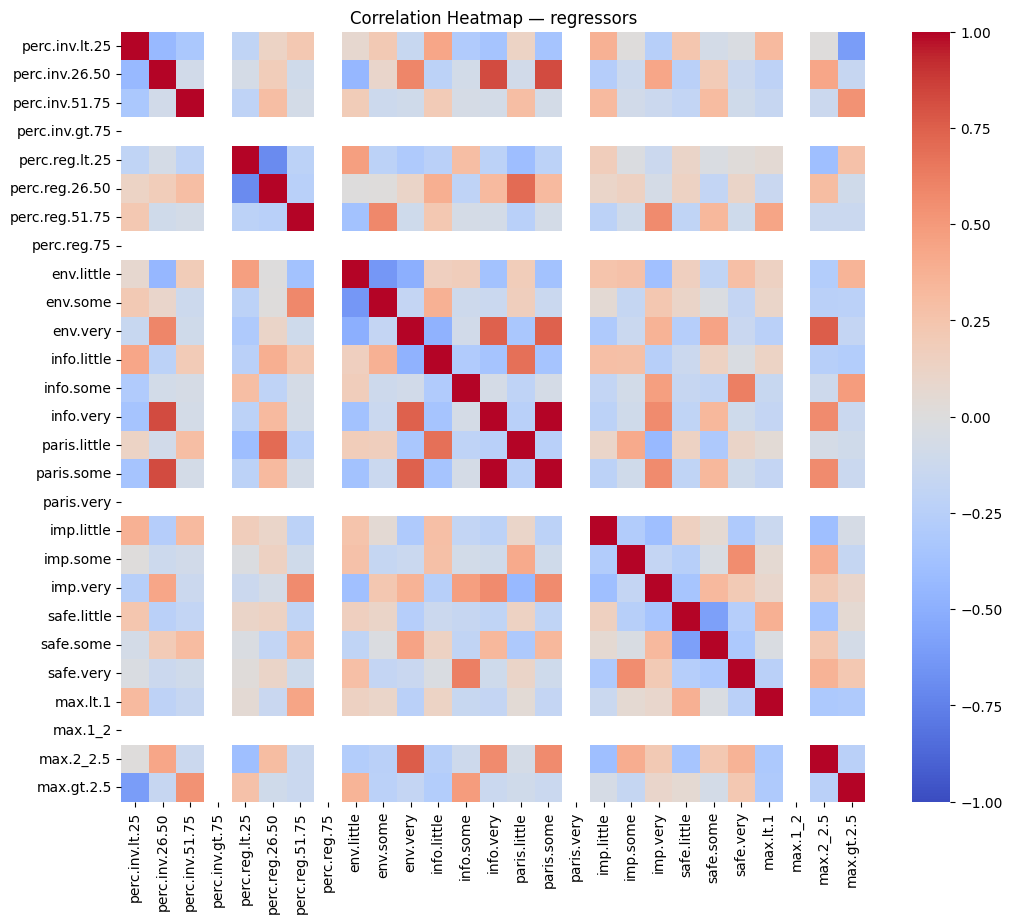


Pairs with |r| ≥ 0.8 (consider merge/drop):
- perc.inv.26.50 ~ info.very: 0.82
- perc.inv.26.50 ~ paris.some: 0.82
- info.very ~ paris.some: 1.0


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

### Select numeric regressors only (exclude targets)
X = (
    df.drop(columns=["y.ipo", "y.real"], errors="ignore")
      .select_dtypes(include="number")
)

### Correlation matrix
corr = X.corr()

### Full heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation Heatmap — regressors")
plt.show()

### Upper-triangle scan for high correlations
def get_high_corr(corr_matrix, threshold=0.8):
    """Return variable pairs with |correlation| >= threshold."""
    pairs = []
    cols = corr_matrix.columns
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            r = corr_matrix.iloc[i, j]
            if abs(r) >= threshold:
                pairs.append((cols[i], cols[j], round(r, 2)))
    return pairs

high_corr_pairs = get_high_corr(corr, threshold=0.8)

print("\nPairs with |r| ≥ 0.8 (consider merge/drop):")
if high_corr_pairs:
    for a, b, r in high_corr_pairs:
        print(f"- {a} ~ {b}: {r}")
else:
    print("No correlations that high found.")


### Step P4 - Cleaning


In [6]:
### Work on a copy and track edits
df_clean = df.copy()
mods = []

### Strong collinearity: keep info.very and drop paris.some (if both exist)
if "paris.some" in df_clean.columns and "info.very" in df_clean.columns:
    df_clean.drop(columns=["paris.some"], inplace=True)
    mods.append("Dropped paris.some")

### Merge suggested by the professor:
### perc.inv.lt.26.50 = perc.inv.lt.25 + perc.inv.26.50 (kept as 0/1 dummy)
if {"perc.inv.lt.25","perc.inv.26.50"}.issubset(df_clean.columns):
    df_clean["perc.inv.lt.26.50"] = (df_clean["perc.inv.lt.25"] + df_clean["perc.inv.26.50"]).clip(0, 1)
    df_clean.drop(columns=["perc.inv.lt.25","perc.inv.26.50"], inplace=True)
    mods.append("Created perc.inv.lt.26.50; dropped perc.inv.lt.25 and perc.inv.26.50")

### Constant variables (all values identical, incl. all 0 or all 1)
drop_const_cols = [
    c for c in df_clean.columns
    if c not in ["y.ipo","y.real"] and df_clean[c].nunique(dropna=False) == 1
]
if drop_const_cols:
    df_clean.drop(columns=drop_const_cols, inplace=True)
    mods.append(f"Dropped constant variables: {drop_const_cols}")

### Summary of applied changes
print("Applied changes:")
print(mods if mods else "— None")

### Final regressors list for modeling
final_regressors = [
    c for c in df_clean.columns
    if c not in ["y.ipo","y.real","predicted_prob","predicted_class"]
]
print("\n# Final regressors:", len(final_regressors))
print(sorted(final_regressors))

### Residual high correlations check (|r| ≥ 0.8) after cleaning
if final_regressors:
    corr2 = df_clean[final_regressors].astype(float).corr()
    high_pairs = []
    cols = corr2.columns
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            r = corr2.iloc[i, j]
            if abs(r) >= 0.8:
                high_pairs.append((cols[i], cols[j], round(r, 2)))
    print("\nPairs still with |r| ≥ 0.8:")
    print(high_pairs if high_pairs else "— None")

### Persist for next steps
df_model = df_clean.copy()  ### we will use df_model going forward
print("\nModel dataframe shape:", df_model.shape)


Applied changes:
['Dropped paris.some', 'Created perc.inv.lt.26.50; dropped perc.inv.lt.25 and perc.inv.26.50', "Dropped constant variables: ['perc.inv.gt.75', 'perc.reg.75', 'paris.very', 'max.1_2']"]

# Final regressors: 21
['env.little', 'env.some', 'env.very', 'imp.little', 'imp.some', 'imp.very', 'info.little', 'info.some', 'info.very', 'max.2_2.5', 'max.gt.2.5', 'max.lt.1', 'paris.little', 'perc.inv.51.75', 'perc.inv.lt.26.50', 'perc.reg.26.50', 'perc.reg.51.75', 'perc.reg.lt.25', 'safe.little', 'safe.some', 'safe.very']

Pairs still with |r| ≥ 0.8:
— None

Model dataframe shape: (97, 23)


### Step P5 - Logistic Regression, we start with y.ipo as target


In [7]:
import warnings
import statsmodels.api as sm
from statsmodels.tools.sm_exceptions import PerfectSeparationWarning, ConvergenceWarning

### Build X and y
regressors = [c for c in df_model.columns if c not in {"y.ipo","y.real","predicted_prob","predicted_class"}]
X = sm.add_constant(df_model[regressors].astype(float), has_constant="add")
y = df_model["y.ipo"].astype(int)

### Fit Logit with clean warning handling
try:
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=PerfectSeparationWarning)
        warnings.filterwarnings("ignore", category=ConvergenceWarning)
        logit_yipo = sm.Logit(y, X).fit(disp=False, warn_convergence=False)

    print("=== Classic Logit — y.ipo ===")
    print(logit_yipo.summary())
except Exception as e:
    print(f"Classic Logit failed for y.ipo: {type(e).__name__}: {e}")
    


Classic Logit failed for y.ipo: LinAlgError: Singular matrix


### Step P6 - Save Clean Dataset for R


In [ ]:
import os

### Export cleaned dataset for R workflow
export_path = "model_data.csv"
df_model.to_csv(export_path, index=False)

print("Saved to:", export_path)
print("Shape:", df_model.shape)   ### 21 regressors + 2 targets
print("Columns:", list(df_model))


Saved to: C:\Users\alans\OneDrive\Desktop\durham\dataset_e_coding\df_per_codice_R.csv
Shape: (97, 23)
Columns: ['perc.inv.51.75', 'perc.reg.lt.25', 'perc.reg.26.50', 'perc.reg.51.75', 'env.little', 'env.some', 'env.very', 'info.little', 'info.some', 'info.very', 'paris.little', 'imp.little', 'imp.some', 'imp.very', 'safe.little', 'safe.some', 'safe.very', 'max.lt.1', 'max.2_2.5', 'max.gt.2.5', 'y.ipo', 'y.real', 'perc.inv.lt.26.50']
